In [1]:
import numpy as np
import gpboost as gpb
import pandas as pd
from pdpbox import pdp

import matplotlib.pyplot as plt

from interpretation_utils import generate_shap_plots

In [2]:
TIME_VERSIONING_DATA_PATH = "data/processed_data/time_versioning/"
TRAINED_MODELS_DATA_PATH = "trained_models/"

stfeature_cols = ["year_default", "X_centroid", "Y_centroid", "credit_score", "occupancy", "nr_units", "loan_purpose", "first_time_homebuyer", "MSA", 
                "insurance_percent", "original_debt_to_income", "original_loan_to_value", "original_upb", "number_of_borrowers", "ir_spread", 
                "n_months", "ltv_at_default", "gdp_growth", "ln_income_per_capita", "ln_expenditures_per_capita", "unemployment_rate", 
                "hpi_growth", "gdp_construction_growth", "gross_operating_surplus_growth", "inflation_rate", "DJIA_growth"]
target_col = ["LGD"]
stcoords_cols = ["year_default", "X_centroid", "Y_centroid"]
categorical_cols = ["occupancy", "loan_purpose", "first_time_homebuyer", "MSA", "number_of_borrowers"]

N_features = 27

In [3]:
# We consider ZOCTN_ST_Bst2020
year = 2020

# We construct graphs with only 10000 sampled observations to prevent overcrowding
N_sample = 10000
train_df = pd.read_feather(TIME_VERSIONING_DATA_PATH+f"{year}_snapshot/training_data.feather")
sample_df = train_df.sample(n=N_sample)

X_train_df, Y_train_df = sample_df[stfeature_cols], sample_df[target_col]
coords_train_df = X_train_df[stcoords_cols]

# Drop year_default from feature matrix
X_train_df = X_train_df.drop(['year_default'], axis=1)
X_train_df = pd.get_dummies(X_train_df, columns=categorical_cols, drop_first=True)

# Loading STGPB Model
stgpb_bst = gpb.Booster(model_file=TRAINED_MODELS_DATA_PATH + f"stgpbs/zoctn_{year}.json")

Finished loading model, total used 304 iterations


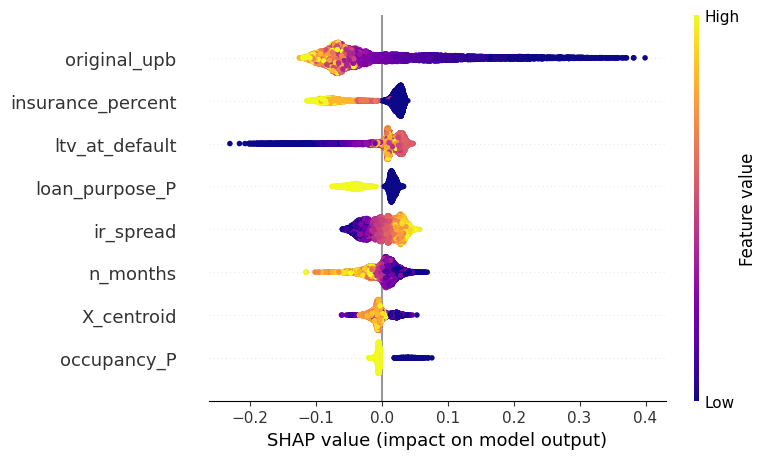

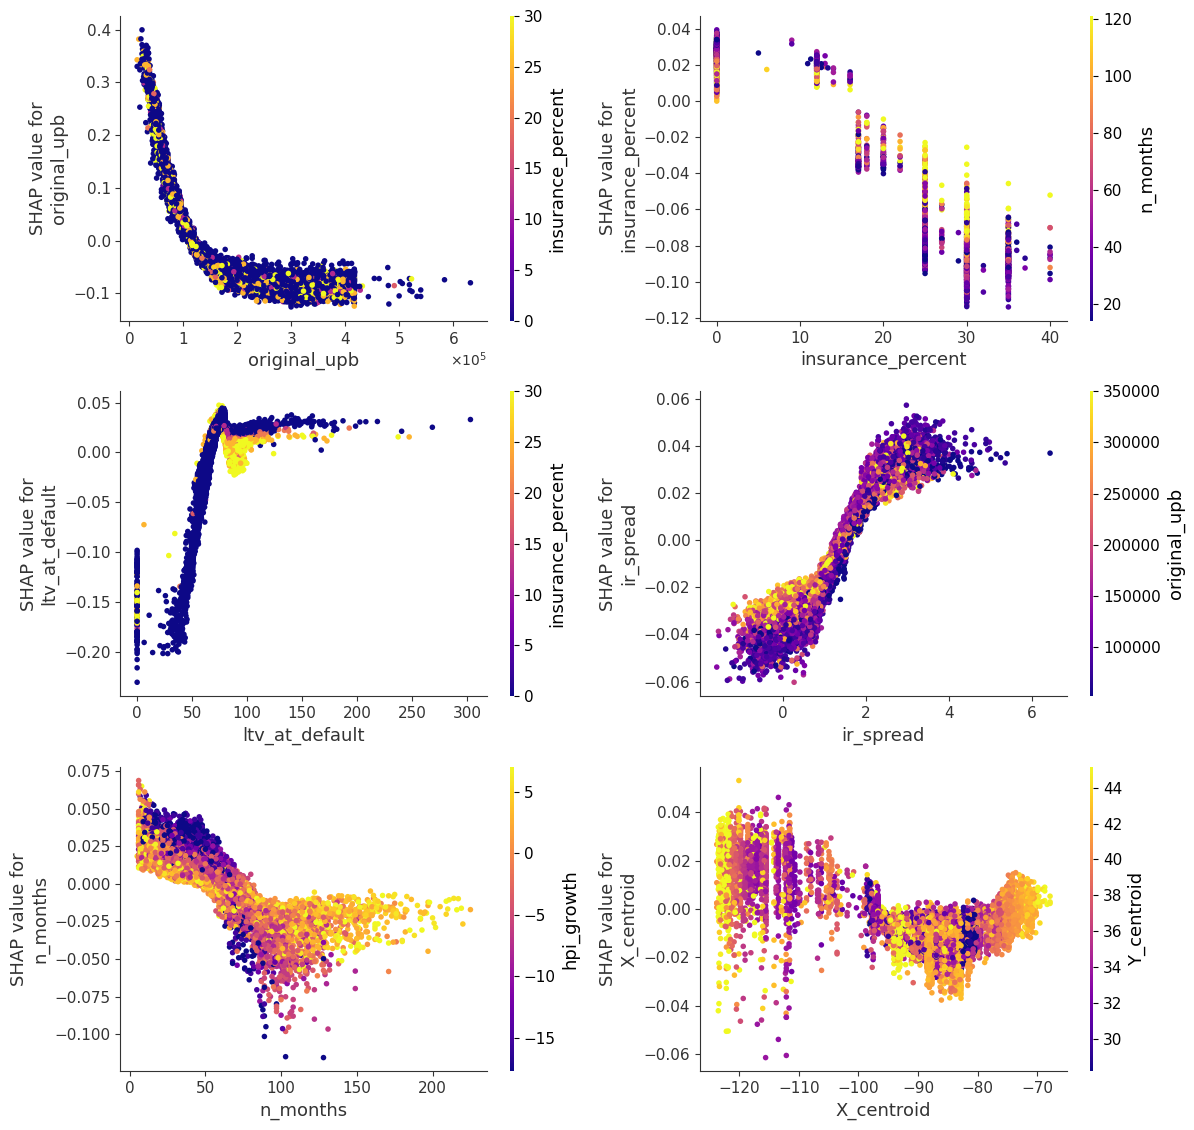

In [4]:
generate_shap_plots(
    stgpb_bst,
    X_train_df,
    feature_names=None,
    output_dir="shap_figures",
    sample_size=10000,
    random_state=42,
    max_display=8,
    numeric_features=None,
    interaction_method={"original_upb": "insurance_percent", "ltv_at_default": "insurance_percent", "X_centroid": "Y_centroid"},
    class_index=None,
    show=True,
)